# Figure 3: Dynamics of decision parameters across action costs.

## setup and imports

In [22]:
import fnmatch
import matplotlib.pyplot as plt
import numpy as np
import glob

from sessionlists import (dist60, dist90, dist120, TM20, TM10, TM2, TMrev2, TMrev10, TMrev20)
from utils import *
from plotting import *
from model_functions import *

plt.style.use('./Figures/paper.mplstyle')

In [23]:
# Define folder with data
root = "/home/thomas/Desktop/ALLDATA"

print("Path to data is: %s"%root)
print(f'Found {len(glob.glob(root+"/*"))} rats in the data folder')

Path to data is: /home/thomas/Desktop/ALLDATA
Found 34 rats in the data folder


In [24]:
rat_markers = {}
sequence = {}

# INTACT RATS
animalList = ['RatF30', 'RatF31', 'RatM30', 'RatF40', 'RatF41', 'RatM41', 'RatM42',
            'RatF50', 'RatF51', 'RatF52', 'RatM50', 'RatM51', 'RatM52']
x = 0
palette = create_kiwi_green_palette(num_shades=len(animalList))
for index, animal in enumerate(animalList):
    print(f'Loading data for {animal}')
    if fnmatch.fnmatch(animal, 'Rat*'):
        rat_markers[animal]=[palette[x], 'o']
        x += 1
    elif fnmatch.fnmatch(animal, 'Rat00*'):
        rat_markers[animal]=[(0.0, 0.0, 0.0), "$\u2426$",]
    else:
        print("error, this is not a rat you got here")
   
    for session in sorted(matchsession(animal, dist60+dist90+dist120 + TM20+TM10+TM2+TMrev2+TMrev10+TMrev20)):
        sequence[animal, session] = get_from_pickle(root, animal[0:6], session, name="sequence.p")


Loading data for RatF30
Loading data for RatF31
Loading data for RatM30
Loading data for RatF40
Loading data for RatF41
Loading data for RatM41
Loading data for RatM42
Loading data for RatF50
Loading data for RatF51
Loading data for RatF52
Loading data for RatM50
Loading data for RatM51
Loading data for RatM52


In [25]:
alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))
ex_alpha_0, ex_alpha_t, ex_alpha_u, ex_gamma_0, ex_gamma_t, ex_gamma_u = pickle.load(open("picklejar/example_session_fit_inter_run_duration.p", "rb"))
ex_mu_0, ex_mu_t, ex_mu_u, ex_sigma_0, ex_sigma_t, ex_sigma_u = pickle.load(open("picklejar/example_session_fit_run_duration.p", "rb"))

PLOT_PARAMS = {
    'alpha_0':  dict(fit=alpha_0, ex_fit= ex_alpha_0, yticks=[0, 1, 2, 3], ylabel=r'$\alpha_0$', start='med', end=2),
    'alpha_t':  dict(fit=alpha_t, ex_fit= ex_alpha_t, yticks=[-.1, 0, .1, .2, .3, .4, .5], ylabel=r'$\alpha_t$', start='med', end=0.4),
    'alpha_u':  dict(fit=alpha_u, ex_fit= ex_alpha_u, yticks=[-.4, -.2, 0, .2, .4], ylabel=r'$\alpha_u$', start=.15, end=.3),
    'gamma_0':  dict(fit=gamma_0, ex_fit= ex_gamma_0, yticks=[0, 0.5, 1, 1.5, 2], ylabel=r'$\gamma_0$', start=1, end=.1),
    'gamma_t':  dict(fit=gamma_t, ex_fit= ex_gamma_t, yticks=[-.2, -.1, 0, .1], ylabel=r'$\gamma_t$', start='med', end=-.15),
    'gamma_u':  dict(fit=gamma_u, ex_fit= ex_gamma_u, yticks=[-.6, -.4, -.2, 0, .2], ylabel=r'$\gamma_u$', start='med', end=-.4),
    'mu_0':     dict(fit=mu_0, ex_fit= ex_mu_0, yticks=[.5, 1, 1.5, 2, 2.5], ylabel=r'$\mu_0$', start='med', end='med'),
    'mu_t':     dict(fit=mu_t, ex_fit= ex_mu_t, yticks=[0, 0.05, .10, .15, .2], ylabel=r'$\mu_t$', start='med', end=.12),
    'mu_u':     dict(fit=mu_u, ex_fit= ex_mu_u, yticks=[-.1, 0, .1, .2], ylabel=r'$\mu_u$', start=0.05, end=.15),
    'sigma_0':  dict(fit=sigma_0, ex_fit= ex_sigma_0, yticks=[0, .05, .1, .15, .2, .25], ylabel=r'$\sigma_0$', start='med', end=.15),
    'sigma_t':  dict(fit=sigma_t, ex_fit= ex_sigma_t, yticks=[-.06, -.03, 0, .03, .06], ylabel=r'$\sigma_t$', start='med', end=0.04),
    'sigma_u':  dict(fit=sigma_u, ex_fit= ex_sigma_u, yticks=[-.03, 0, .03, .06, .09, .12], ylabel=r'$\sigma_u$', start='med', end=0.08),
}


# 3B Effect of distance on α0, αt and αu
# 3C Effect of distance on γ0, γt and γu

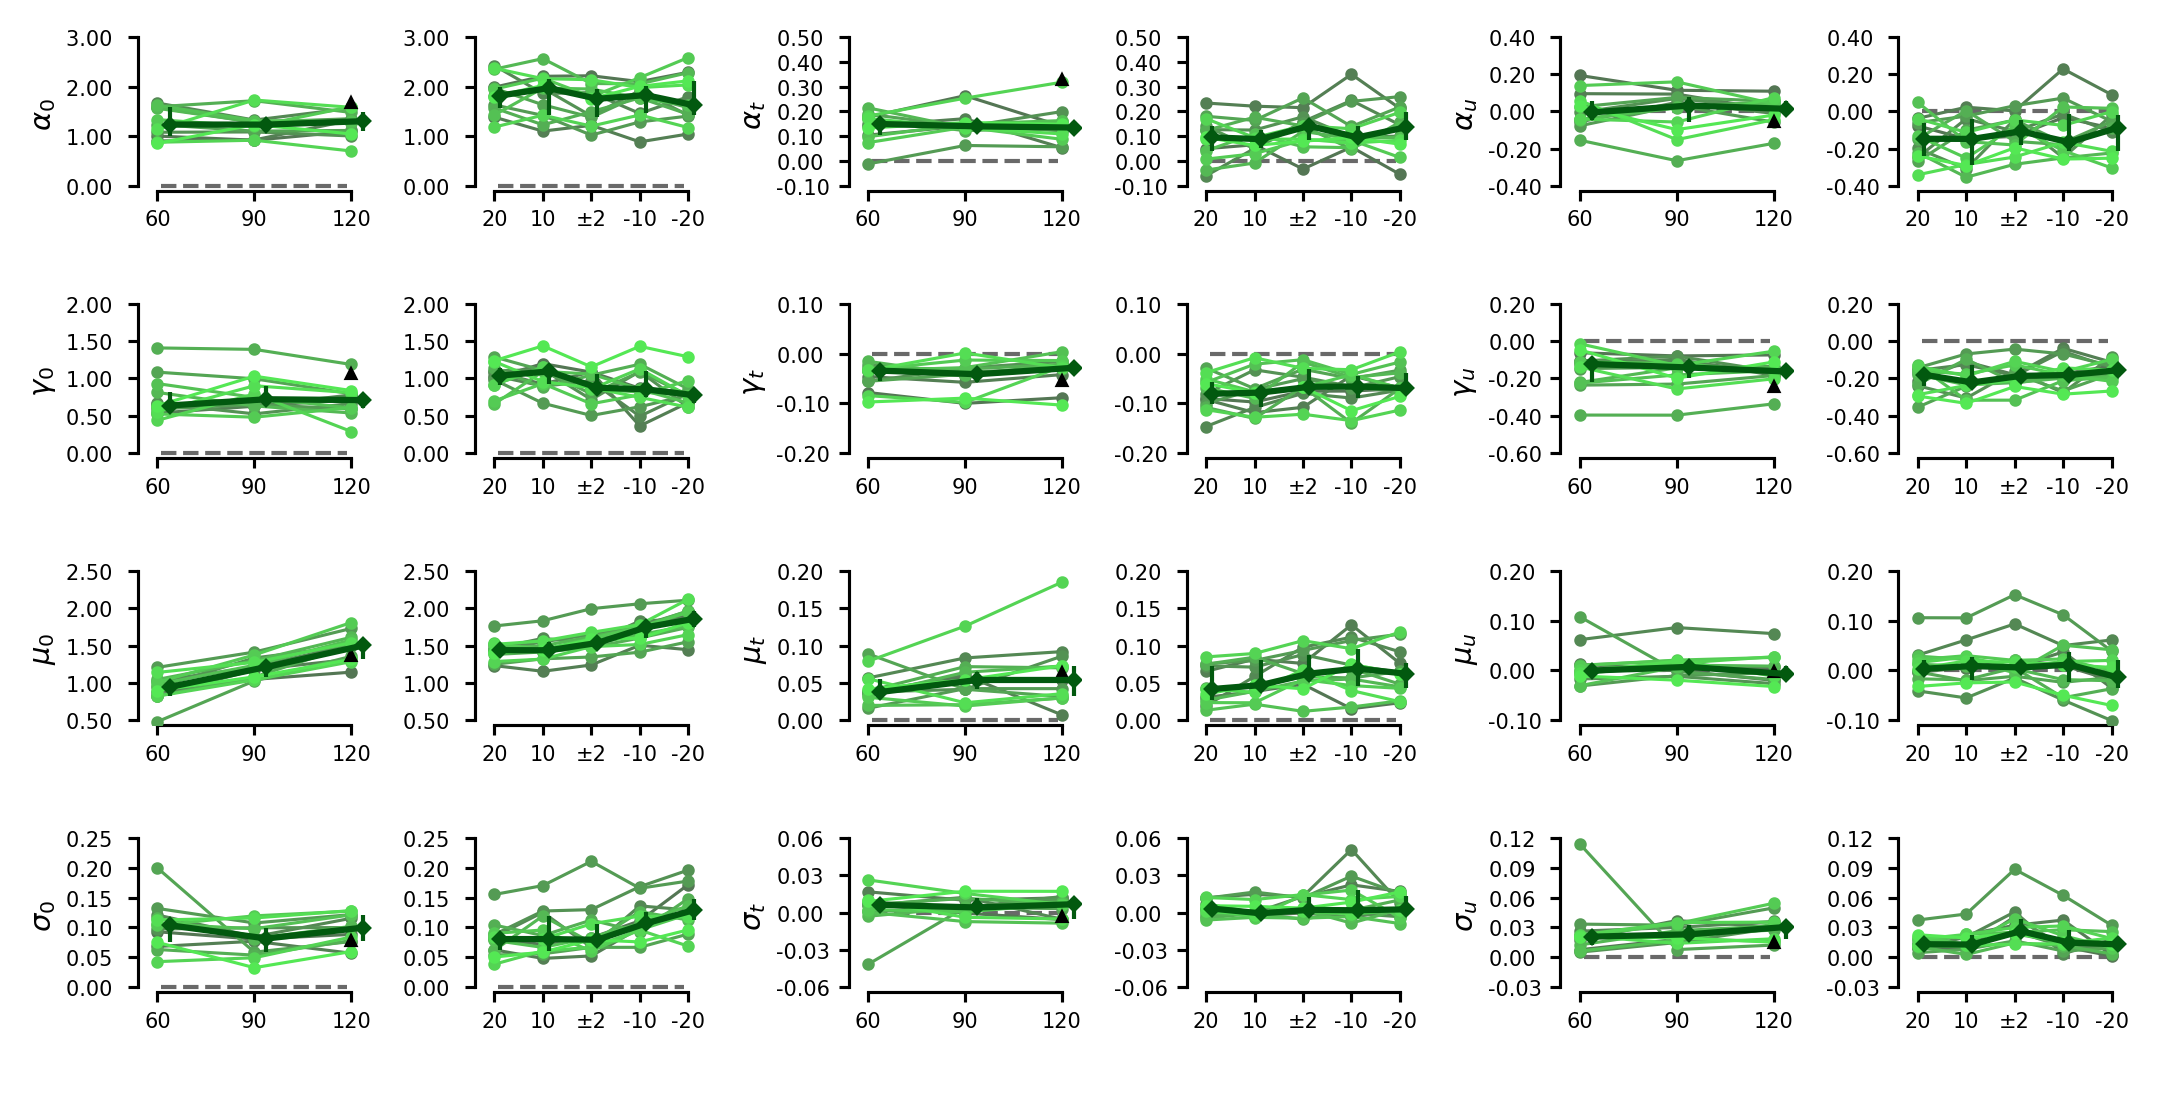

In [ ]:

def plot_model_parameter(param_name, dist_or_tm='dist', show_ex=False, ax=None, show_xlabel=False, show_ylabel=False, hide_y=False,
                         lesioned_animals=False, median_color='k'):

    if not lesioned_animals:
        animalList = ['RatF00', 'RatF01', 'RatF02', 'RatM00', 'RatM01', 'RatM02', 
            'RatF32', 'RatF33', 'RatM31', 'RatM32', 'RatF42', 'RatM40', 'RatM43', 'RatM53', 'RatM54']
    else:
        animalList = ['RatF30', 'RatF31', 'RatM30', 'RatF40', 'RatF41', 'RatM41', 'RatM42',
            'RatF50', 'RatF51', 'RatF52', 'RatM50', 'RatM51', 'RatM52']

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    params = PLOT_PARAMS[param_name]
    if dist_or_tm == 'dist':
        x = [0, 1, 2]
        conds = ["60", "90", "120"]
        xticklabels = ["60", "90", "120"]
        _ = r'$d$'
        xlabel = f'{_} (cm)'
    elif dist_or_tm == 'tm':
        x = [0, 1, 2, 3, 4]
        conds = ["20", "10", "2", "rev10", "rev20"]
        xticklabels = ["20", "10", "±2", "-10", "-20"]
        _ = r'$v_{belt}$'
        xlabel = f'{_} (cm/s)'

    for animal in animalList:
        ax.plot(x, [params['fit'][animal][cond] for cond in conds], 
                    color=rat_markers[animal][0], marker=rat_markers[animal][1], lw=.75,
                    markersize=2, zorder=8 if animal=='RatM00' else 5)
        
    if show_ex:
        ax.plot(2, params['ex_fit'], color='black', marker='^', zorder=10, markersize=2, linewidth=0, label='Example session')


    ax.axhline(0, color='dimgray', linestyle='--', linewidth=1, alpha=1, zorder=0, xmin=.1, xmax=.9)

    ax.set_xlim(x[0], x[-1])
    ax.set_xticks(x)
    ax.set_xticklabels(xticklabels)
    if show_xlabel:
        ax.set_xlabel(xlabel)
    else:
        ax.set_xlabel(" ")

    ax.set_ylim(params['yticks'][0], params['yticks'][-1])
    ax.set_yticks(params['yticks'])
    if param_name not in ['run_speed', 'run_speed_lesion']:
        ax.yaxis.set_major_formatter('{x:<5.2f}')
    if show_ylabel:
        ax.set_ylabel(params['ylabel'])
    if hide_y:
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False, labelleft=False)

    space_axes(ax, x_ratio_left=.1, x_ratio_right=.1)
    plotmedian(params['fit'], ax=ax, dist_or_tm=dist_or_tm, animalList=animalList, err='percentile', color=median_color)



fig, axs = plt.subplots(4, 6, figsize=(cm2inch(18), cm2inch(9)))
param_names = [name for name in list(PLOT_PARAMS.keys()) for _ in (0, 1)]

for i, ax in enumerate(axs.ravel()):
    if i % 2 == 0:
        dist_or_tm = 'dist'
    else:
        dist_or_tm = 'tm'

    show_xlabel = False
    show_ylabel = True if i % 2 == 0 else False
    show_ex = True if i % 2 == 0 else False
    plot_model_parameter(param_names[i], dist_or_tm=dist_or_tm, show_ex=show_ex, ax=ax, 
                         show_xlabel=show_xlabel, show_ylabel=show_ylabel, lesioned_animals=True,
                         median_color='xkcd:deep green')


In [34]:
dist_shuffled_slopes, dist_p_value_slope, dist_observed_slope = [], [], []
dist_shuffled_intercepts, dist_p_value_intercept, dist_observed_intercept = [], [], []
tm_shuffled_slopes, tm_p_value_slope, tm_observed_slope = [], [], []
tm_shuffled_intercepts, tm_p_value_intercept, tm_observed_intercept = [], [], []

vars = [alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u][::-1]
names = [r'$\alpha_0$', r'$\alpha_t$', r'$\alpha_U$', r'$\gamma_0$', r'$\gamma_t$', r'$\gamma_U$', r'$\mu_0$', r'$\mu_t$', r'$\mu_U$', r'$\sigma_0$', r'$\sigma_t$', r'$\sigma_U$'][::-1]
for var in vars:
    shuffled_slopes, p_value_slope, observed_slope, shuffled_intercepts, p_value_intercept, observed_intercept = compute_regression_permutation(var, dist_or_tm='dist', lesioned_animals=True, num_iterations=10000)

    dist_shuffled_slopes.append(shuffled_slopes)
    dist_p_value_slope.append(p_value_slope)
    dist_observed_slope.append(observed_slope)
    dist_shuffled_intercepts.append(shuffled_intercepts)
    dist_p_value_intercept.append(p_value_intercept)
    dist_observed_intercept.append(observed_intercept)

    shuffled_slopes, p_value_slope, observed_slope, shuffled_intercepts, p_value_intercept, observed_intercept = compute_regression_permutation(var, dist_or_tm='tm', lesioned_animals=True, num_iterations=10000)
    tm_shuffled_slopes.append(shuffled_slopes)
    tm_p_value_slope.append(p_value_slope)
    tm_observed_slope.append(observed_slope)
    tm_shuffled_intercepts.append(shuffled_intercepts)
    tm_p_value_intercept.append(p_value_intercept)
    tm_observed_intercept.append(observed_intercept)

p_s=0.578, p_i=0.000, obs_slope=0.002, obs_intercept=0.024
p_s=0.999, p_i=0.000, obs_slope=-0.000, obs_intercept=0.020
p_s=0.849, p_i=0.010, obs_slope=0.000, obs_intercept=0.004
p_s=0.186, p_i=0.000, obs_slope=0.001, obs_intercept=0.003
p_s=0.670, p_i=0.000, obs_slope=-0.003, obs_intercept=0.096
p_s=0.000, p_i=0.000, obs_slope=0.013, obs_intercept=0.076
p_s=0.590, p_i=0.157, obs_slope=-0.003, obs_intercept=0.010
p_s=0.272, p_i=0.157, obs_slope=-0.004, obs_intercept=0.017
p_s=0.164, p_i=0.000, obs_slope=0.009, obs_intercept=0.044
p_s=0.083, p_i=0.000, obs_slope=0.004, obs_intercept=0.051
p_s=0.000, p_i=0.000, obs_slope=0.274, obs_intercept=0.926
p_s=0.000, p_i=0.000, obs_slope=0.103, obs_intercept=1.389
p_s=0.760, p_i=0.000, obs_slope=-0.005, obs_intercept=-0.153
p_s=0.049, p_i=0.000, obs_slope=0.012, obs_intercept=-0.211
p_s=0.256, p_i=0.000, obs_slope=0.006, obs_intercept=-0.050
p_s=0.106, p_i=0.000, obs_slope=0.005, obs_intercept=-0.080
p_s=0.788, p_i=0.000, obs_slope=-0.013, obs_int

# 3E Effect of treadmill on α0, αt and αu
# 3F Effect of treadmill on γ0, γt and γu

# Figure 3: Dynamics of decision parameters across action costs.

/home/thomas/Documents/RunningFastAndSlow/.venv/lib/python3.7/site-packages/IPython/core/pylabtools.py:151: UserWarning: constrained_layout not applied.  At least one axes collapsed to zero width or height.
  fig.canvas.print_figure(bytes_io, **kw)


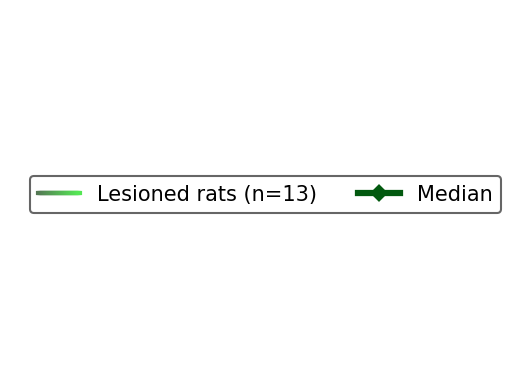

In [35]:
def dummy_legend(ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    
    median_lesion = ax.plot([-100, -101], [-100, -101], color='xkcd:deep green', marker='D', markersize=2, linestyle='-', lw=1.5, label=f'Median lesioned rats', zorder=5)

    add_colored_lesion(ax=ax, loc='center', bbox=(.5, .5), ncol=2,
                       handles=[median_lesion], labels=['Median'],
                       text=f'Lesioned rats (n={len(animalList)})')
    ax.axis('off')
    ax.set_xlim(10, 11)
    ax.set_ylim(10, 11)

fig, axs = plt.subplots(1, 1, figsize=(cm2inch(3), cm2inch(3)))
dummy_legend(ax=axs)

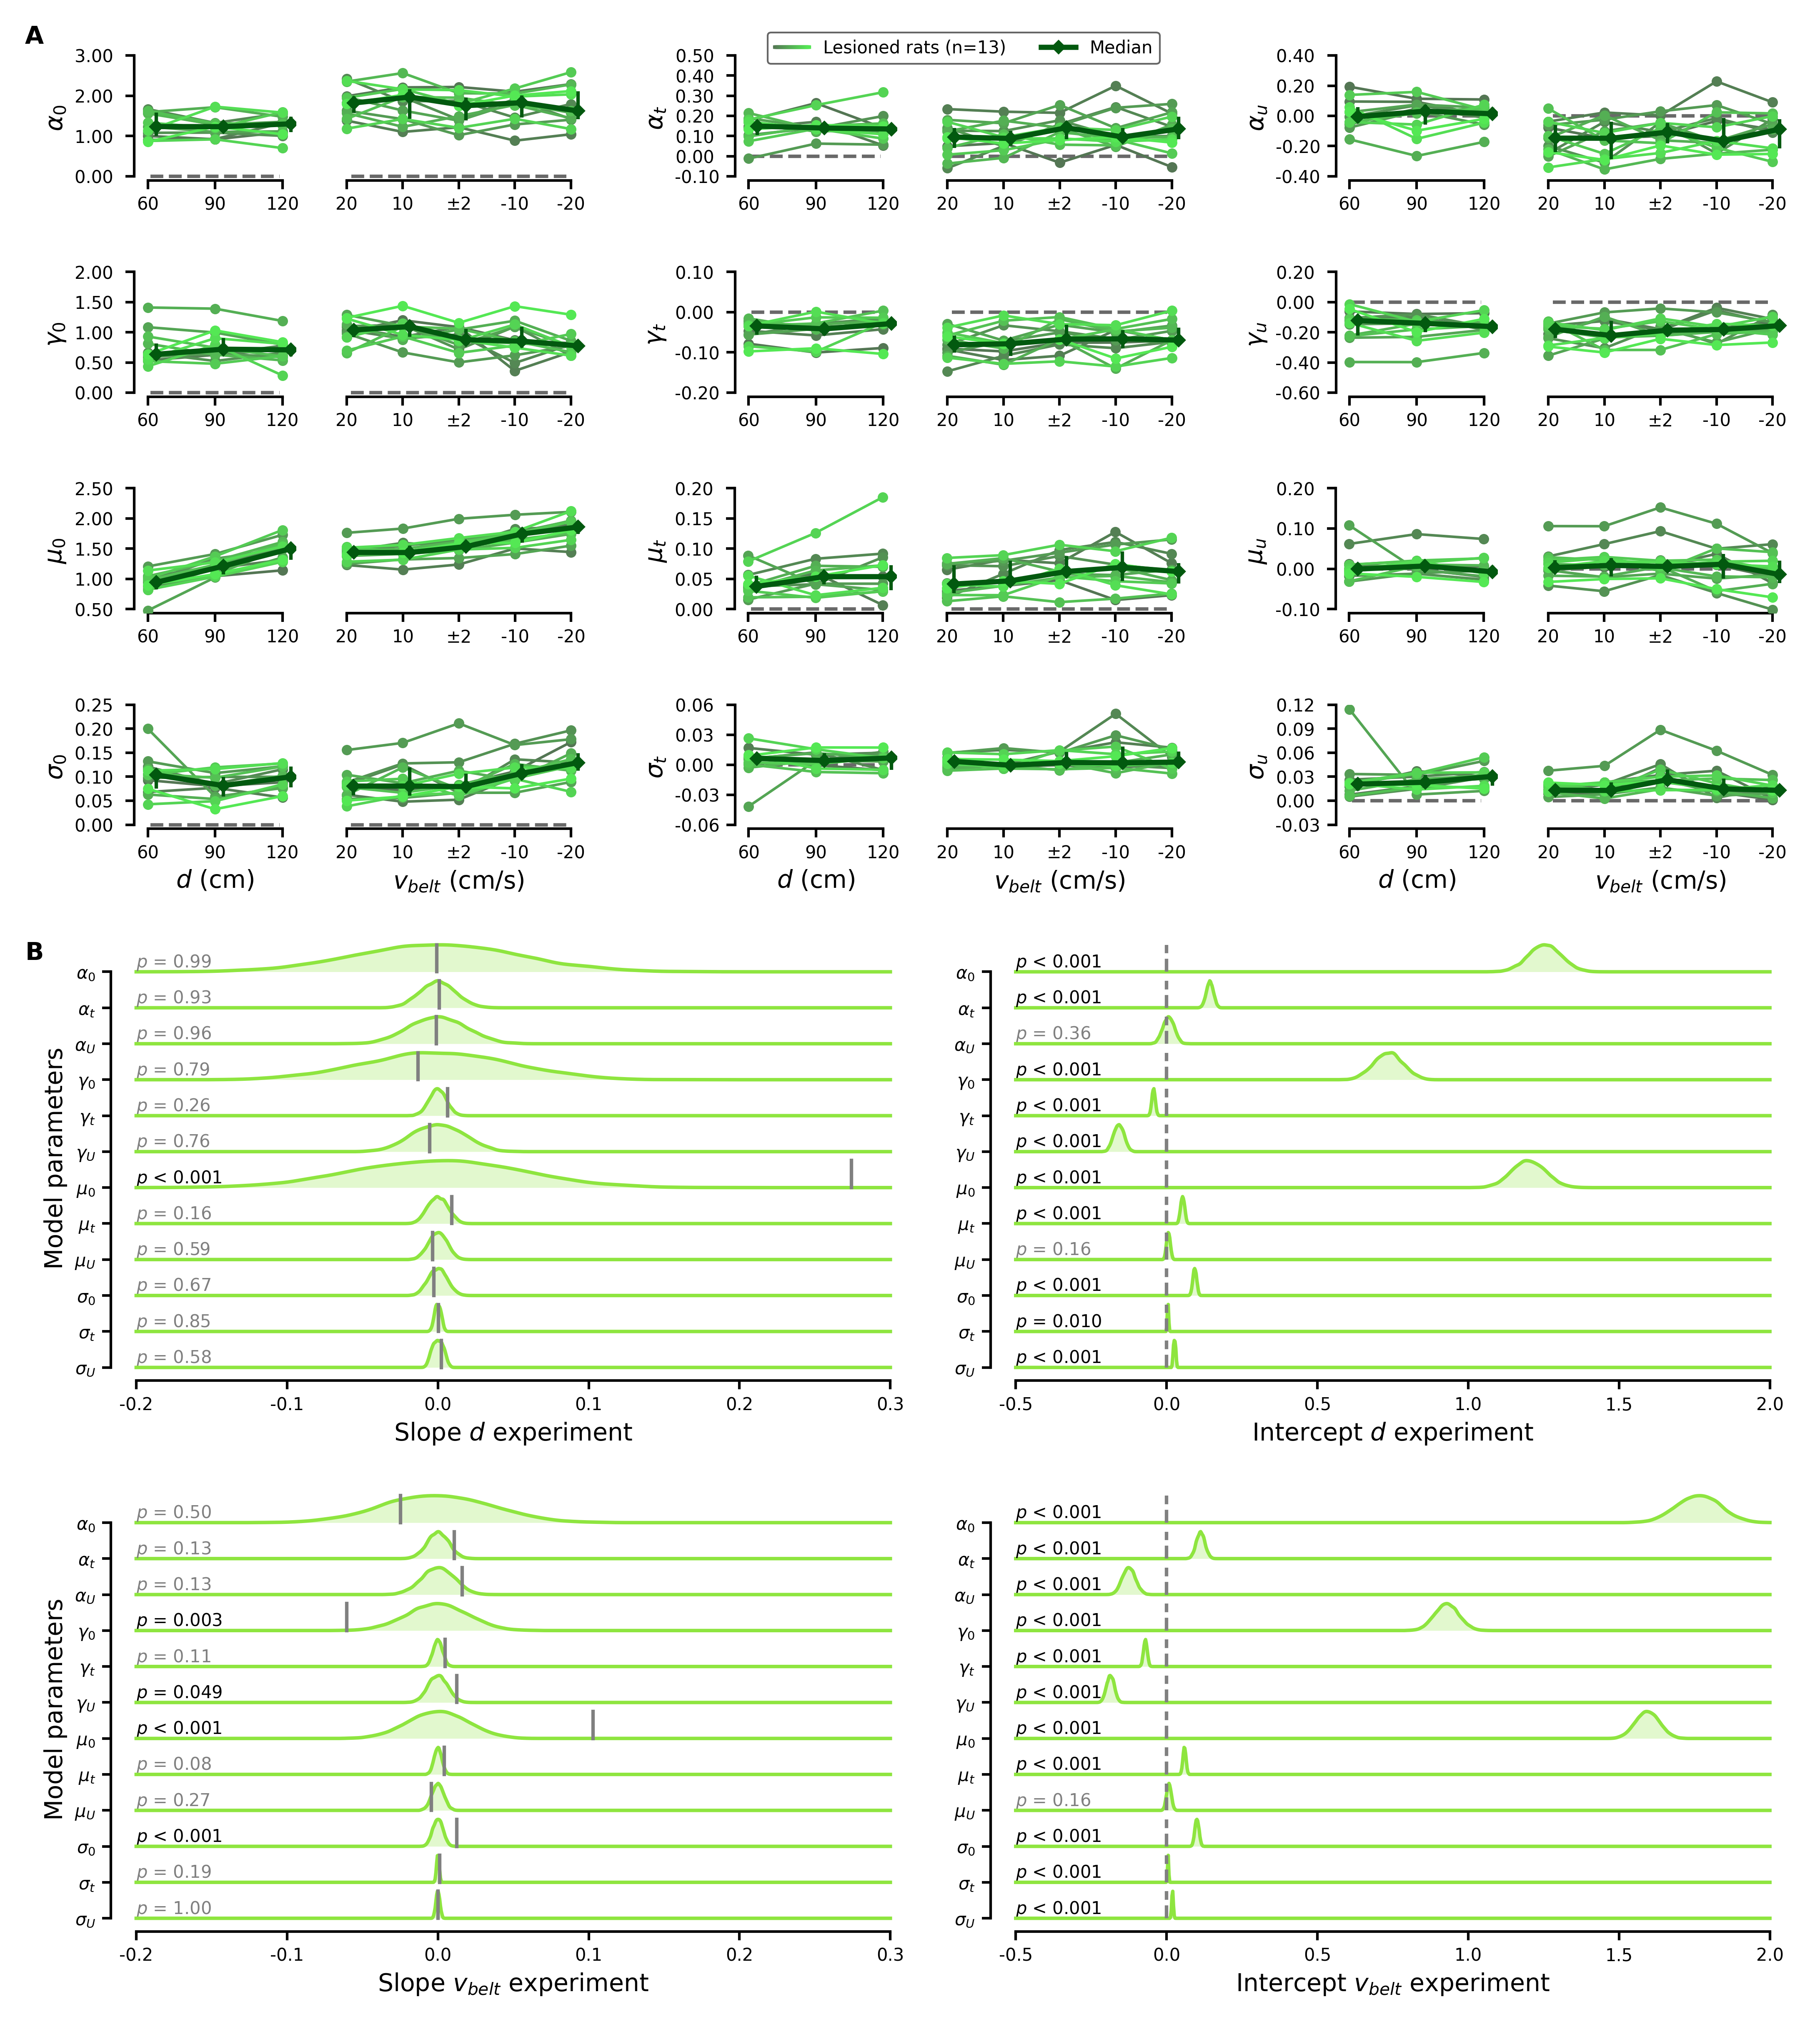

In [ ]:

fig = plt.figure(figsize=(cm2inch(18), cm2inch(20)),
                #  constrained_layout=True,
                 facecolor='w', dpi=600)

pad = 0.0001
width_ratios = [3, 5, pad, 3, 5, pad, 3, 5]
gs0 = fig.add_gridspec(6, 1, height_ratios=[1, 1, 1, 1, .1, 5])

row1 = gs0[0].subgridspec(1, 8, width_ratios=width_ratios)
fit_alpha_0_distance = plt.subplot(row1[0])
fit_alpha_0_vbelt = plt.subplot(row1[1])

fit_alpha_t_distance = plt.subplot(row1[3])
fit_alpha_t_vbelt = plt.subplot(row1[4])

fit_alpha_u_distance = plt.subplot(row1[6])
fit_alpha_u_vbelt = plt.subplot(row1[7])

row2 = gs0[1].subgridspec(1, 8, width_ratios=width_ratios)
fit_gamma_0_distance = plt.subplot(row2[0])
fit_gamma_0_vbelt = plt.subplot(row2[1])

fit_gamma_t_distance = plt.subplot(row2[3])
fit_gamma_t_vbelt = plt.subplot(row2[4])

fit_gamma_u_distance = plt.subplot(row2[6])
fit_gamma_u_vbelt = plt.subplot(row2[7])


row3 = gs0[2].subgridspec(1, 8, width_ratios=width_ratios)
fit_mu_0_distance = plt.subplot(row3[0])
fit_mu_0_vbelt = plt.subplot(row3[1])

fit_mu_t_distance = plt.subplot(row3[3])
fit_mu_t_vbelt = plt.subplot(row3[4])

fit_mu_u_distance = plt.subplot(row3[6])
fit_mu_u_vbelt = plt.subplot(row3[7])

row4 = gs0[3].subgridspec(1, 8, width_ratios=width_ratios)
fit_sigma_0_distance = plt.subplot(row4[0])
fit_sigma_0_vbelt = plt.subplot(row4[1])

fit_sigma_t_distance = plt.subplot(row4[3])
fit_sigma_t_vbelt = plt.subplot(row4[4])

fit_sigma_u_distance = plt.subplot(row4[6])
fit_sigma_u_vbelt = plt.subplot(row4[7])

row5 = gs0[5].subgridspec(2, 2)
ax_slope_d = plt.subplot(row5[0, 0])
ax_intercept_d = plt.subplot(row5[0, 1])
ax_slope_tm = plt.subplot(row5[1, 0])
ax_intercept_tm = plt.subplot(row5[1, 1])

plot_model_parameter('alpha_0', dist_or_tm='dist', show_ex=False, ax=fit_alpha_0_distance, show_ylabel=True, lesioned_animals=True, median_color='xkcd:deep green')
plot_model_parameter('alpha_t', dist_or_tm='dist', show_ex=False, ax=fit_alpha_t_distance, show_ylabel=True, lesioned_animals=True, median_color='xkcd:deep green')
plot_model_parameter('alpha_u', dist_or_tm='dist', show_ex=False, ax=fit_alpha_u_distance, show_ylabel=True, lesioned_animals=True, median_color='xkcd:deep green')
plot_model_parameter('gamma_0', dist_or_tm='dist', show_ex=False, ax=fit_gamma_0_distance, show_ylabel=True, lesioned_animals=True, median_color='xkcd:deep green')
plot_model_parameter('gamma_t', dist_or_tm='dist', show_ex=False, ax=fit_gamma_t_distance, show_ylabel=True, lesioned_animals=True, median_color='xkcd:deep green')
plot_model_parameter('gamma_u', dist_or_tm='dist', show_ex=False, ax=fit_gamma_u_distance, show_ylabel=True, lesioned_animals=True, median_color='xkcd:deep green')
plot_model_parameter('mu_0', dist_or_tm='dist', show_ex=False, ax=fit_mu_0_distance, show_ylabel=True, lesioned_animals=True, median_color='xkcd:deep green')
plot_model_parameter('mu_t', dist_or_tm='dist', show_ex=False, ax=fit_mu_t_distance, show_ylabel=True, lesioned_animals=True, median_color='xkcd:deep green')
plot_model_parameter('mu_u', dist_or_tm='dist', show_ex=False, ax=fit_mu_u_distance, show_ylabel=True, lesioned_animals=True, median_color='xkcd:deep green')
plot_model_parameter('sigma_0', dist_or_tm='dist', show_ex=False, ax=fit_sigma_0_distance, show_xlabel=True, show_ylabel=True, lesioned_animals=True, median_color='xkcd:deep green')
plot_model_parameter('sigma_t', dist_or_tm='dist', show_ex=False, ax=fit_sigma_t_distance, show_xlabel=True, show_ylabel=True, lesioned_animals=True, median_color='xkcd:deep green')
plot_model_parameter('sigma_u', dist_or_tm='dist', show_ex=False, ax=fit_sigma_u_distance, show_xlabel=True, show_ylabel=True, lesioned_animals=True, median_color='xkcd:deep green')


plot_model_parameter('alpha_0', dist_or_tm='tm', show_ex=False, ax=fit_alpha_0_vbelt, lesioned_animals=True, hide_y=True, median_color='xkcd:deep green')
plot_model_parameter('alpha_t', dist_or_tm='tm', show_ex=False, ax=fit_alpha_t_vbelt, lesioned_animals=True, hide_y=True, median_color='xkcd:deep green')
plot_model_parameter('alpha_u', dist_or_tm='tm', show_ex=False, ax=fit_alpha_u_vbelt, lesioned_animals=True, hide_y=True, median_color='xkcd:deep green')
plot_model_parameter('gamma_0', dist_or_tm='tm', show_ex=False, ax=fit_gamma_0_vbelt, lesioned_animals=True, hide_y=True, median_color='xkcd:deep green')
plot_model_parameter('gamma_t', dist_or_tm='tm', show_ex=False, ax=fit_gamma_t_vbelt, lesioned_animals=True, hide_y=True, median_color='xkcd:deep green')
plot_model_parameter('gamma_u', dist_or_tm='tm', show_ex=False, ax=fit_gamma_u_vbelt, lesioned_animals=True, hide_y=True, median_color='xkcd:deep green')
plot_model_parameter('mu_0', dist_or_tm='tm', show_ex=False, ax=fit_mu_0_vbelt, lesioned_animals=True, hide_y=True, median_color='xkcd:deep green')
plot_model_parameter('mu_t', dist_or_tm='tm', show_ex=False, ax=fit_mu_t_vbelt, lesioned_animals=True, hide_y=True, median_color='xkcd:deep green')
plot_model_parameter('mu_u', dist_or_tm='tm', show_ex=False, ax=fit_mu_u_vbelt, lesioned_animals=True, hide_y=True, median_color='xkcd:deep green')
plot_model_parameter('sigma_0', dist_or_tm='tm', show_ex=False, ax=fit_sigma_0_vbelt, show_xlabel=True, lesioned_animals=True, hide_y=True, median_color='xkcd:deep green')
plot_model_parameter('sigma_t', dist_or_tm='tm', show_ex=False, ax=fit_sigma_t_vbelt, show_xlabel=True, lesioned_animals=True, hide_y=True, median_color='xkcd:deep green')
plot_model_parameter('sigma_u', dist_or_tm='tm', show_ex=False, ax=fit_sigma_u_vbelt, show_xlabel=True, lesioned_animals=True, hide_y=True, median_color='xkcd:deep green')

ridgeline(dist_shuffled_slopes, observed_vals=dist_observed_slope, pvals=dist_p_value_slope, overlap=.0, ax=ax_slope_d, labels=names, x_ticks=[-0.2, -0.1, 0, 0.1, 0.2, 0.3], ylabel='Model parameters', xlabel=r'Slope $d$ experiment', color='xkcd:kiwi green')
ridgeline(dist_shuffled_intercepts, observed_vals=dist_observed_intercept, pvals=dist_p_value_intercept, overlap=.0, ax=ax_intercept_d, labels=names, x_ticks=[-0.5, 0, 0.5, 1, 1.5, 2], show_zero=True, xlabel=r'Intercept $d$ experiment', color='xkcd:kiwi green')
ridgeline(tm_shuffled_slopes, observed_vals=tm_observed_slope, pvals=tm_p_value_slope, overlap=.0, ax=ax_slope_tm, labels=names, x_ticks=[-0.2, -0.1, 0, 0.1, 0.2, 0.3], ylabel='Model parameters', xlabel=r'Slope $v_{belt}$ experiment', color='xkcd:kiwi green')
ridgeline(tm_shuffled_intercepts, observed_vals=tm_observed_intercept, pvals=tm_p_value_intercept, overlap=.0, ax=ax_intercept_tm, labels=names, x_ticks=[-0.5, 0, 0.5, 1, 1.5, 2], show_zero=True, xlabel=r'Intercept $v_{belt}$ experiment', color='xkcd:kiwi green')


legend = fig.add_axes([.52, .99, .01, .01])
dummy_legend(ax=legend)

add_all_letters([fit_alpha_0_distance, ax_slope_d], ["A", "B"])


plt.savefig("./Figures_paper/Figure_S1213.pdf", facecolor='w', 
        edgecolor='none', bbox_inches='tight', format="pdf", dpi=600)
plt.savefig("./Figures_paper/Figure_S1213.svg", facecolor='w', 
        edgecolor='none', bbox_inches='tight', format="svg", dpi=600)